In [1]:
import sys
sys.path.append("../src")

In [2]:
import importlib
import utils
importlib.reload(utils)

from utils import add_enrollment_per_1000, clean_analysis_df, make_classification_target

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

figures_dir = Path("../figures")
figures_dir.mkdir(exist_ok=True)

merged_df = pd.read_csv("../data/processed/MD_merged_crime_college.csv")

In [4]:
import numpy as np
np.random.seed(42)

In [5]:
merged_df = add_enrollment_per_1000(merged_df)
merged_df = clean_analysis_df(merged_df)

print("columns after add+clean:", merged_df.columns.tolist())
print("has enrollment_per_1000?", "enrollment_per_1000" in merged_df.columns)

df, threshold = make_classification_target(merged_df)

columns after add+clean: ['county_clean', 'crime_total', 'crime_rate', 'population', 'Annual Number of Public High School Graduates', '2-Year College Enrollment', 'enroll_4yr', 'college_enrollment_total', 'enrollment_per_1000']
has enrollment_per_1000? True


In [6]:
#create classification target using median split
# 1 = low enrollment, 0 = high enrollment (binary outcome)

threshold = df["enrollment_per_1000"].median()
df["low_enrollment"] = (df["enrollment_per_1000"] < threshold).astype(int)
df["low_enrollment"].value_counts()

low_enrollment
0    12
1    12
Name: count, dtype: int64

In [7]:
#features & labels
x = df[["crime_rate", "population"]]
y = df["low_enrollment"]

In [8]:
#train/test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42, stratify=y
)

In [9]:
#standardize for logistic regression
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [10]:
#Model 1 - Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(x_train_scaled, y_train)

y_pred_lr = log_reg.predict(x_test_scaled)
y_prob_lr = log_reg.predict_proba(x_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
roc_lr = roc_auc_score(y_test, y_prob_lr)

acc_lr, roc_lr

(0.16666666666666666, 0.11111111111111112)

In [11]:
#confusion matrix
plt.figure()
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression - Confusion Matrix")

plt.tight_layout()
plt.savefig(figures_dir / "confusion_matrix_logistic.png", dpi=200)
plt.close()

<Figure size 640x480 with 0 Axes>

In [12]:
#Model 2 - Random Forest
rf = RandomForestClassifier(
    n_estimators = 300,
    random_state = 42,
    max_depth = None
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)
y_prob_rf = rf.predict_proba(x_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, y_prob_rf)

acc_rf, roc_rf

(0.6666666666666666, 0.6666666666666666)

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

<Figure size 640x480 with 0 Axes>

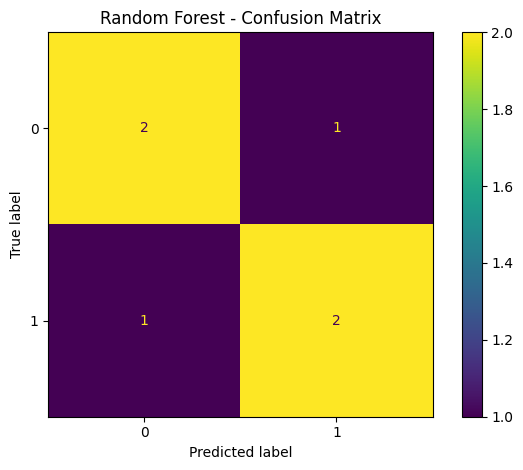

In [13]:
#confusion matrix - RF
plt.figure()
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest - Confusion Matrix")

plt.tight_layout()
plt.savefig(figures_dir / "confusion_matrix_randomforest.png", dpi=200)
plt.close

In [14]:
#save model performance
model_results = pd.DataFrame([
    {"model": "logistic_regression", "accuracy": acc_lr, "roc_auc": roc_lr},
    {"model": "random_forest", "accuracy": acc_rf, "roc_auc": roc_rf},
])

model_results.to_csv("../data/processed/model_results.csv", index=False)

model_results

,model,accuracy,roc_auc
0,logistic_regression,0.166667,0.111111
1,random_forest,0.666667,0.666667


We trained two binary classifiers to predict low versus high college enrollment per capita using neighborhood crime rate and population as predictors.

Logistic regression performed poorly, achieving an accuracy of 0.17 and a ROC-AUC of 0.11, showing a linear decision boundary is insufficient to capture the relationship between violent crime and enrollment outcomes in this dataset.

In contrast, the random forest model achieved an accuracy of 0.67 and a ROC-AUC of 0.67, suggesting moderate predictive ability and improved sensitivity to nonlinear interactions between crime rates and population size.

Overall, these results indicate that while violent crime alone has limited explanatory power, nonlinear modeling approaches can extract modest predictive signal from neighborhood-level features. However, the relatively small sample size and absence of key socioeconomic variables (e.g., income, school funding, unemployment, educational attainment) constrain model performance and limit generalizability.